In [29]:
import pandas as pd
import numpy as np
import requests
import re
import os
import geopandas
import matplotlib.pyplot as plt
from shapely.geometry import LineString
import time
import pickle
import random
import shap

pd.set_option('display.max_columns', None)
os.environ["LOKY_MAX_CPU_COUNT"] = "8"

# Make Mapping

### Hydro Data

In [3]:
# Load Hydro Stations and filter to BC
hydro_stations_df = pd.read_csv('mapping_files/hydrometric_StationList.csv')
hydro_stations_df = hydro_stations_df[hydro_stations_df['Prov/Terr'] == 'BC']

hydro_stations_gdf = geopandas.GeoDataFrame(
    hydro_stations_df, geometry=geopandas.points_from_xy(hydro_stations_df.Longitude, hydro_stations_df.Latitude), crs="EPSG:4326"
)

hydro_stations_gdf.rename(columns={'ID': 'Hydro ID', 'Name / Nom' : 'Hydro Station', 'Latitude': 'Hydro Lat', 'Longitude': 'Hydro Long', 'geometry': 'Hydro Geometry'}, inplace=True)
hydro_stations_gdf = hydro_stations_gdf[['Hydro ID', 'Hydro Station', 'Hydro Lat', 'Hydro Long', 'Hydro Geometry']]
hydro_stations_gdf = hydro_stations_gdf.set_geometry('Hydro Geometry').to_crs(epsg=3005)


# Load Hydro Station Detail File
bcub_df = pd.read_csv('BCUB_attributes_20240630.csv')

bcub_gdf = geopandas.GeoDataFrame(
    bcub_df, geometry=geopandas.points_from_xy(bcub_df.centroid_x, bcub_df.centroid_y), crs="EPSG:3005"
)

# Join together and map to station
hydro_stations_gdf = geopandas.sjoin_nearest(
    hydro_stations_gdf, 
    bcub_gdf, 
    how="left", 
    distance_col="Distance"
)

hydro_stations_gdf['Distance'] = hydro_stations_gdf['Distance'] / 1000  #Convert from m to km
hydro_stations_gdf = hydro_stations_gdf.sort_values(by='Distance')
hydro_stations_gdf = hydro_stations_gdf[['Hydro ID', 'Hydro Station', 'Hydro Lat', 'Hydro Long', 'Hydro Geometry', 'drainage_area_km2', 'elevation_m',
                                        'aspect_deg', 'slope_deg', 'porosity_x100', 'outside_pct_area_flag', 'land_use_snow_ice_frac_2020', 'land_use_wetland_frac_2020',
                                        'land_use_forest_frac_2020', 'logk_ice_x100']]

### Climate Data

In [4]:
# Load Climate stations
climate_stations_df = pd.read_csv('mapping_files/climate_station_list.csv')
climate_stations_df = climate_stations_df[climate_stations_df['DLY First Year'] <= 2018]
climate_stations_df = climate_stations_df[climate_stations_df['DLY Last Year'] >= 2025]
climate_stations_df = climate_stations_df[climate_stations_df['Province'] == 'BRITISH COLUMBIA']

# Filter out stations that do not show precipitation
bad_climate_stations = ['1021270', '1022795', '1015628', '1015630', '1025365', '1038210', 
                         '1046396', '1060848', '1086081', '1100032', '1157635', '1160902', 
                         '1173214', '1126518', '1026562', '1157631', '1160899', '1173214', 
                         '1015628', '1026639', '1031353', '1090660', '1101571', '1106764', 
                         '1125079', '1166658', '10253G0', '1106PF7', '116Q20D', '1161650',
                         '1114619', '1168204', '1181513', '1036570', '1021330', '1026565',
                         '1073615', '1020590', '1085836', '1036572', '116QK0M', '1012055']
climate_stations_df = climate_stations_df[~climate_stations_df['Climate ID'].isin(bad_climate_stations)]


climate_stations_gdf = geopandas.GeoDataFrame(
    climate_stations_df, geometry=geopandas.points_from_xy(climate_stations_df.Longitude, climate_stations_df.Latitude), crs="EPSG:4326"
)

climate_stations_gdf.rename(columns={'Station Name': 'Climate Station', 'Latitude': 'Climate Lat', 'Longitude': 'Climate Long', 'geometry': 'Climate Geometry'}, inplace=True)
climate_stations_gdf = climate_stations_gdf[['Climate ID', 'Climate Station', 'Climate Lat', 'Climate Long', 'Climate Geometry']]
climate_stations_gdf = climate_stations_gdf.set_geometry('Climate Geometry').to_crs(epsg=3005)

### Join and Filter

In [13]:
# Join Hydro and Climate stations by nearest distance
gdf_cross = geopandas.sjoin_nearest(
    hydro_stations_gdf, 
    climate_stations_gdf, 
    how="left", 
    distance_col="Distance"
)

# Drop stations that are here twice due to identical distance
gdf_cross['Distance'] = gdf_cross['Distance'] / 1000  #Convert from m to km
gdf_cross = gdf_cross.sort_values(by='Distance')
gdf_cross = gdf_cross.drop_duplicates(['Hydro ID'])

# Write 
gdf_cross_filtered = gdf_cross[gdf_cross['Distance'] < 25] 
gdf_cross_filtered.to_csv("Hydro_to_Climate_Mapping.csv", index=False)

## Plot Station Selection

In [16]:
# Add back climate geometry as removed in mapping closest station
gdf_cross = pd.merge(gdf_cross, climate_stations_gdf[['Climate ID', 'Climate Geometry']], on = 'Climate ID', how='left')

gdf_cross['line_geom'] = [LineString([a, b]) for a, b in zip(gdf_cross['Hydro Geometry'], gdf_cross['Climate Geometry'])]
gdf_cross = gdf_cross.set_geometry('line_geom')
gdf_cross.crs = "EPSG:3005"
gdf_cross = gdf_cross.to_crs(epsg=3005)

bc_boundary = geopandas.read_file("mapping_files/bc_boundary.gpkg") 
bc_boundary = bc_boundary.to_crs(epsg=3005)

In [17]:
gdf_cross

,Hydro ID,Hydro Station,Hydro Lat,Hydro Long,Hydro Geometry,drainage_area_km2,elevation_m,aspect_deg,slope_deg,porosity_x100,outside_pct_area_flag,land_use_snow_ice_frac_2020,land_use_wetland_frac_2020,land_use_forest_frac_2020,logk_ice_x100,index_right,Climate ID,Climate Station,Climate Lat,Climate Long,Distance,Climate Geometry,line_geom
0,08HB006,PUNTLEDGE RIVER AT COURTENAY,49.68803,-125.03419,POINT (1069715.624 519566.842),3,38,68,2.4,0.0,0,0,3,40,-1413.0,1722,1021989,COURTENAY PUNTLEDGE,49.69,-125.03,0.373430,POINT (1070015.054 519789.984),"LINESTRING (1069715.624 519566.842, 1070015.05..."
1,08NA006,KICKING HORSE RIVER AT GOLDEN,51.30118,-116.97207,POINT (1627089.311 738670.261),6,915,233,8.3,0.0,0,0,1,47,-1052.0,2832,1173210,GOLDEN A,51.30,-116.98,0.567757,POINT (1626558.174 738469.657),"LINESTRING (1627089.311 738670.261, 1626558.17..."
2,08GD008,HOMATHKO RIVER AT INLET TO TATLAYOKO LAKE,51.67322,-124.40722,POINT (1109994.626 741321.485),2,994,250,8.9,0.0,0,0,0,54,-1052.0,7487,1088015,TATLAYOKO LAKE RCS,51.67,-124.40,0.614356,POINT (1110501.251 740973.974),"LINESTRING (1109994.626 741321.485, 1110501.25..."
3,08NL039,SIWASH CREEK NEAR PRINCETON,49.66281,-120.33553,POINT (1408682.347 532646.601),1,1079,122,13.7,0.0,0,0,2,72,-1052.0,3539,1123721,JELLICOE,49.67,-120.33,0.893582,POINT (1409016.518 533475.346),"LINESTRING (1408682.347 532646.601, 1409016.51..."
4,08FE003,KEMANO RIVER ABOVE POWERHOUSE TAILRACE,53.56355,-127.95236,POINT (870992.543 952682.298),1,158,227,21.0,1.0,0,0,2,54,-1410.0,3657,1064020,KEMANO,53.56,-127.94,0.907847,POINT (871798.203 952263.851),"LINESTRING (870992.543 952682.298, 871798.203 ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
431,07EA007,AKIE RIVER NEAR THE 760 M CONTOUR,57.19111,-124.90111,POINT (1066334.331 1356262.461),1,763,159,3.3,0.0,0,0,1,75,-1495.0,2553,1192946,FORT NELSON A,58.84,-122.60,228.545782,POINT (1196347.534 1544224.536),"LINESTRING (1066334.331 1356262.461, 1196347.5..."
432,10BE013,SMITH RIVER NEAR THE MOUTH,59.55353,-126.48025,POINT (972794.083 1618998.017),3,468,179,4.5,0.0,0,0,1,9,-1052.0,2553,1192946,FORT NELSON A,58.84,-122.60,235.727001,POINT (1196347.534 1544224.536),"LINESTRING (972794.083 1618998.017, 1196347.53..."
433,07EA005,FINLAY RIVER ABOVE AKIE RIVER,57.12622,-125.24992,POINT (1045356.125 1348750.212),1,705,258,2.2,0.0,0,0,0,95,-1052.0,7403,107G879,SUSKWA VALLEY,55.29,-127.17,236.881503,POINT (925867.442 1144213.416),"LINESTRING (1045356.125 1348750.212, 925867.44..."
434,09AA001,ATLIN LAKE AT ATLIN,59.57253,-133.70547,POINT (564576.681 1644739.321),2,692,258,5.2,0.0,0,0,1,89,-1052.0,1907,119BLM0,DEASE LAKE (AUT),58.43,-130.03,246.666065,POINT (764708.741 1500547.414),"LINESTRING (564576.681 1644739.321, 764708.741..."


### All Stations

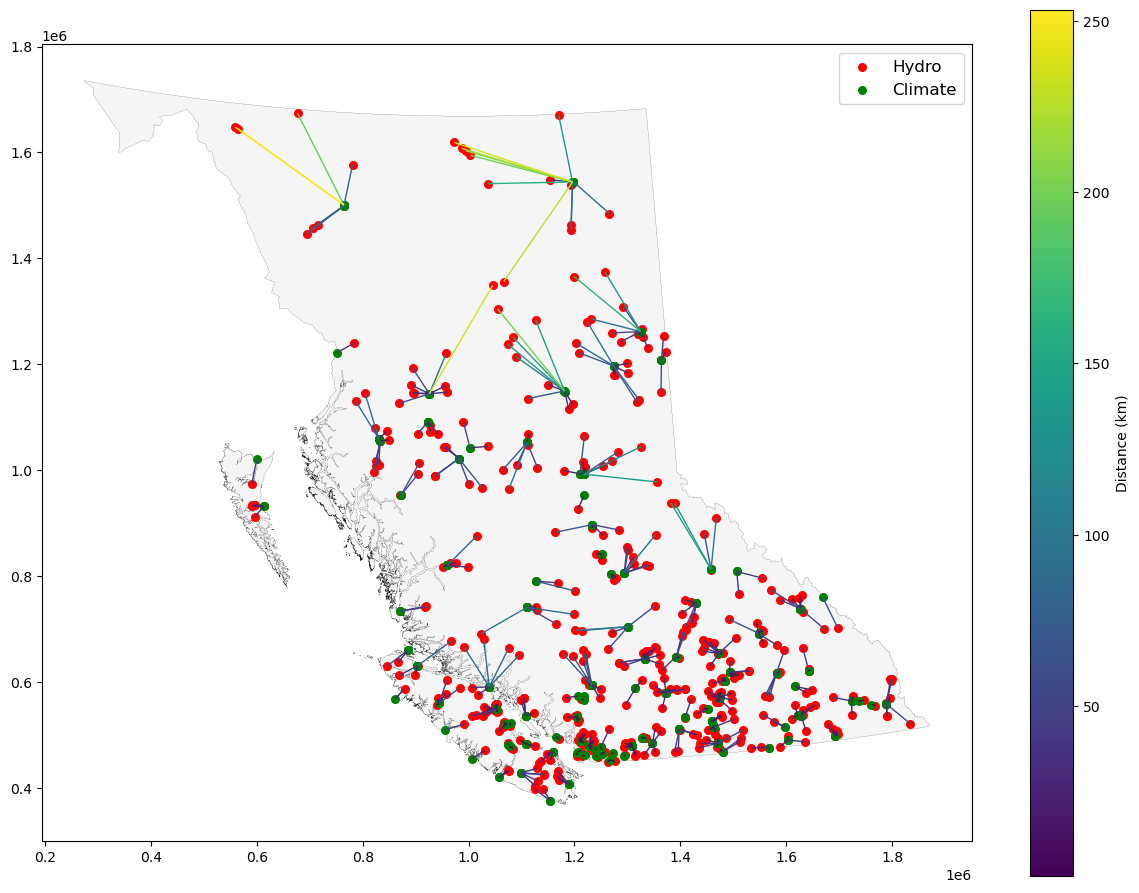

Hydro Station Count: 436
Climate Station Count: 115


In [18]:
fig, ax = plt.subplots(figsize=(15, 15))
bc_boundary.plot(ax=ax, color='whitesmoke', edgecolor='black', linewidth=0.1)

gdf_cross.set_geometry('Hydro Geometry').plot(ax=ax, color='red', marker='o', label='Hydro', markersize=30)
gdf_cross.set_geometry('Climate Geometry').plot(ax=ax, color='green', marker='o', label='Climate', markersize=30)
gdf_cross.set_geometry('line_geom').plot(ax=ax, column='Distance', cmap='viridis', linewidth=1, legend=True, legend_kwds={'label': "Distance (km)", 'shrink' : 0.75})

ax.legend(loc='upper right', fontsize='large', frameon=True)
plt.show()

print(f"Hydro Station Count: {len(gdf_cross['Hydro ID'].unique())}")
print(f"Climate Station Count: {len(gdf_cross['Climate ID'].unique())}")

### Stations used for model

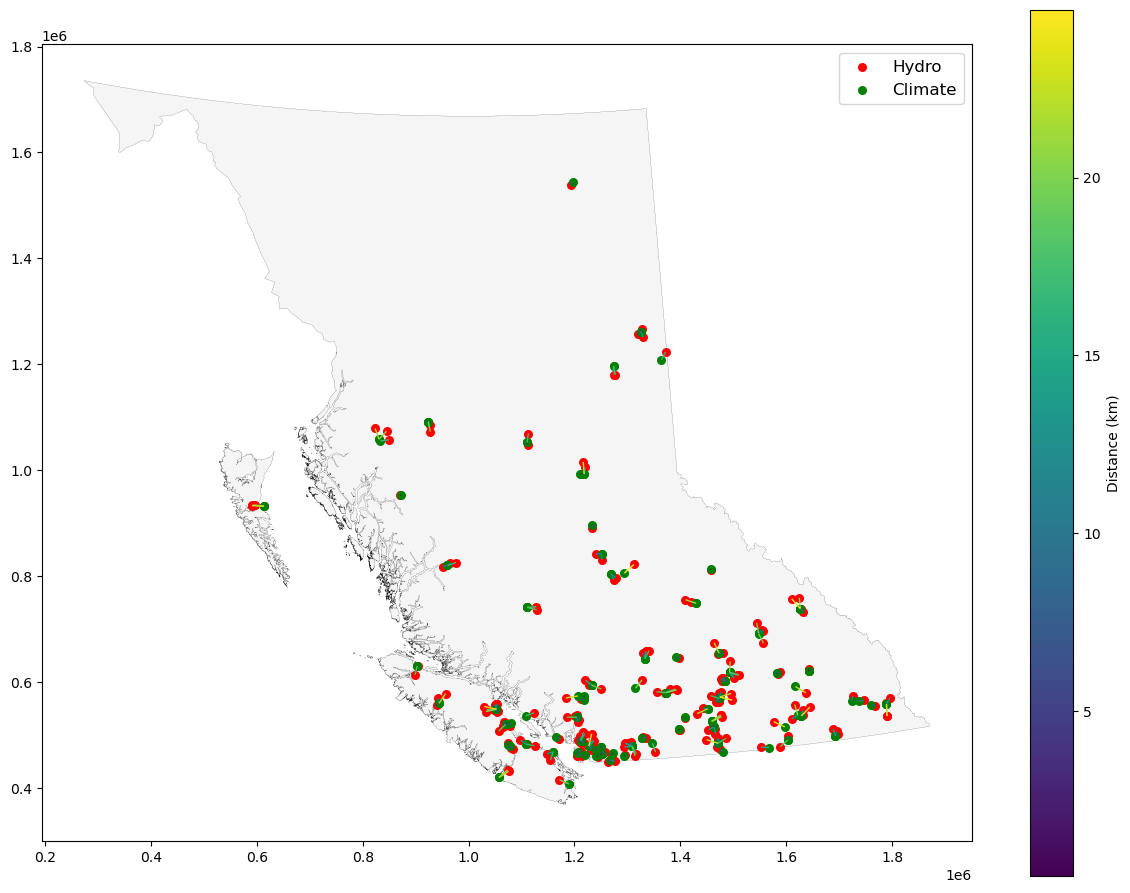

Hydro Station Count: 209
Climate Station Count: 87


In [19]:
gdf_cross_filtered = gdf_cross[gdf_cross['Distance'] < 25] 

fig, ax = plt.subplots(figsize=(15, 15))
bc_boundary.plot(ax=ax, color='whitesmoke', edgecolor='black', linewidth=0.1)

gdf_cross_filtered.set_geometry('Hydro Geometry').plot(ax=ax, color='red', marker='o', label='Hydro', markersize=30)
gdf_cross_filtered.set_geometry('Climate Geometry').plot(ax=ax, color='green', marker='o', label='Climate', markersize=30)
gdf_cross_filtered.set_geometry('line_geom').plot(ax=ax, column='Distance', cmap='viridis', linewidth=1, legend=True, legend_kwds={'label': "Distance (km)", 'shrink' : 0.75})

ax.legend(loc='upper right', fontsize='large', frameon=True)
plt.show()

print(f"Hydro Station Count: {len(gdf_cross_filtered['Hydro ID'].unique())}")
print(f"Climate Station Count: {len(gdf_cross_filtered['Climate ID'].unique())}")

# Make Train Set

### Hydro Data and Target Variable

In [20]:
hydro_stations = pd.read_csv("Hydro_to_Climate_Mapping.csv")['Hydro ID'].values

base_path = 'hydro_files'
hydro_headers = ['UTC', 'Datetime', 'Value', 'Approval', 'Grade', 'Qualifier']

output = []
for folder in os.listdir(base_path):
    hydro_id = re.search(r'@([A-Z0-9]+)', folder).group(1)
    if hydro_id in hydro_stations:
        file_path = os.path.join(base_path, folder)
        hydro_df = pd.read_csv(file_path, skiprows=15, compression='xz', header=None, names=hydro_headers, on_bad_lines='skip', low_memory=False)
        hydro_df['Datetime'] = pd.to_datetime(hydro_df['Datetime'], errors='coerce')
    
        # Set start date for files and customize date if sensor changed heights mid way through file to only include new sensor height data
        start_date = '2017-12-01'
        if hydro_id == '07FC001':
            start_date = '2018-05-01'
        elif hydro_id == '08HD024':
            start_date = '2019-01-11'
        elif hydro_id == '08NJ061':
            start_date = '2020-09-01'
        hydro_df = hydro_df[hydro_df['Datetime'] > start_date]

        # Remove misread data
        if hydro_id == '08NM240':
            daily_avg = daily_avg.drop(pd.Timestamp('2025-10-12'))
            
        # Get Daily water level average/max/min 
        daily_avg = hydro_df.groupby(hydro_df['Datetime'].dt.floor('D'))['Value'].agg(['mean', 'max', 'min'])

        # Remove rows with large date gaps
        time_diff = pd.Series(daily_avg.index).diff()
        gap = time_diff > pd.Timedelta(days=7)
        before_gap = gap.shift(-1)
        rows_to_remove = (gap | before_gap).fillna(False)
        daily_avg = daily_avg[~rows_to_remove.values]

        # Turn all values below 0 to and add a constant to every value so a log can be ran
        daily_avg['mean_shifted'] = daily_avg['mean'].clip(lower=0) + 1 # constant 1
        daily_avg['log_mean'] = np.log(daily_avg['mean_shifted'])

        daily_avg['max_shifted'] = daily_avg['max'].clip(lower=0) + 1
        daily_avg['log_max'] = np.log(daily_avg['max_shifted'])
        
        daily_avg['min_shifted'] = daily_avg['min'].clip(lower=0) + 1
        daily_avg['log_min'] = np.log(daily_avg['min_shifted'])

        daily_avg['log_range'] = daily_avg['log_max'] - daily_avg['log_min']
    
        # Create column for real expanding mean and std
        daily_avg['exp_mean'] = daily_avg['log_mean'].expanding(min_periods=30).mean()
        daily_avg['exp_std'] = daily_avg['log_mean'].expanding(min_periods=30).std().clip(lower=0.1) # Add floor standard deviaion to prevent early exploding z scores

        # Make column for last day and two days ago water level
        daily_avg['log_mean-1'] = daily_avg['log_mean'].shift(1)
        daily_avg['log_mean-2'] = daily_avg['log_mean'].shift(2)
        daily_avg['flow_velocity'] = daily_avg['log_mean-1'] - daily_avg['log_mean-2']
        daily_avg['log_range-1'] = daily_avg['log_range'].shift(1)

        # Drop First 30 rows Before mean and average are settled
        daily_avg = daily_avg.iloc[30:]
    
        # Make Target and shift exp_mean and std so can be used for prediciton as if average from previous day
        daily_avg['Hydro ID'] = hydro_id
        daily_avg['target'] = (daily_avg['log_mean'] - daily_avg['exp_mean']) / daily_avg['exp_std']
        daily_avg['exp_mean-1'] = daily_avg['exp_mean'].shift(1)
        daily_avg['exp_std-1'] = daily_avg['exp_std'].shift(1)
        output.append(daily_avg.copy())

        if len(output) % 51 == 0:
            print(str(len(output) // 51 * 25) + "%")


hydro_data = pd.concat(output)
hydro_data.to_csv('train_hydro_data.csv')

25%
50%
75%
100%


### Climate Data

In [21]:
climate_stations = pd.read_csv("Hydro_to_Climate_Mapping.csv")['Climate ID'].unique()

base_path = 'climate_files'

output = []
for folder in os.listdir(base_path):
    climate_id = re.search(r'BC_([a-zA-Z0-9]+)_\d{4}', folder).group(1)
    if climate_id in climate_stations:
        file_path = os.path.join(base_path, folder)
        climate_df = pd.read_csv(file_path, encoding='latin1')

        # Rename columns to remove characters with measures in name and match column names from other tables
        new_names = {}
        for col in climate_df.columns:
            if 'Max Temp (' in col: new_names[col] = 'temp_max'
            elif 'Min Temp (' in col: new_names[col] = 'temp_min'
            elif 'Mean Temp (' in col: new_names[col] = 'temp_mean'
            elif 'Total Rain (' in col: new_names[col] = 'precip_rain'
            elif 'Total Snow (' in col: new_names[col] = 'precip_snow'
            elif 'Total Precip (' in col: new_names[col] = 'precip_total'
            elif 'Snow on Grnd (' in col: new_names[col] = 'snow_depth'
            elif 'Date/Time' in col: new_names[col] = 'Datetime'
        climate_df = climate_df.rename(columns=new_names)
        climate_df = climate_df[['Climate ID', 'Datetime', 'temp_max', 'temp_min', 'temp_mean', 'precip_rain', 'precip_snow', 'precip_total', 'snow_depth', 'Month']]

        # Measure only include climate with latest hydro dates
        climate_df['Datetime'] = pd.to_datetime(climate_df['Datetime'], errors='coerce')
        climate_df = climate_df[climate_df['Datetime'] <= '2025-10-25']
        climate_df = climate_df.reset_index(drop=True)

        # Infer Temp values that are missing
        for col in ['temp_max', 'temp_min', 'temp_mean']:
            station_month_medians = climate_df.groupby(['Climate ID', 'Month'])[col].transform('median')
            climate_df[col] = climate_df[col].fillna(station_month_medians)
        
        # IF missing an entire month fill with that months temperature history
        for col in ['temp_max', 'temp_min', 'temp_mean']:
            global_month_medians = climate_df.groupby('Month')[col].transform('median')
            climate_df[col] = climate_df[col].fillna(global_month_medians)
        
        # Some files give total precipitation but not specific uses temperature to determine which it was fill that in
        calculated_total = climate_df['precip_rain'].fillna(0) + climate_df['precip_snow'].fillna(0)
        mask_repair_total = climate_df['precip_total'].isna() & (climate_df['precip_rain'].notna() | climate_df['precip_snow'].notna())
        climate_df.loc[mask_repair_total, 'precip_total'] = calculated_total
        
        # Some files give total but not rain or snow fill those in
        mask_to_partition = (
            climate_df['precip_total'].notna() & 
            climate_df['precip_rain'].isna() & 
            climate_df['precip_snow'].isna()
        )
        
        # Assign to Rain
        warm_mask = mask_to_partition & (climate_df['temp_mean'] > 0)
        climate_df.loc[warm_mask, 'precip_rain'] = climate_df['precip_total']
        climate_df.loc[warm_mask, 'precip_snow'] = 0
        
        # Assign to Snow
        cold_mask = mask_to_partition & (climate_df['temp_mean'] <= 0)
        climate_df.loc[cold_mask, 'precip_snow'] = climate_df['precip_total']
        climate_df.loc[cold_mask, 'precip_rain'] = 0
        
        climate_df[['precip_rain', 'precip_snow', 'precip_total', 'snow_depth']] = climate_df[['precip_rain', 'precip_snow', 'precip_total', 'snow_depth']].fillna(0)

        climate_df['precip_3d'] = climate_df['precip_total'].rolling(window=3, min_periods=3).sum()
        climate_df['precip_7d'] = climate_df['precip_total'].rolling(window=7, min_periods=7).sum()
        climate_df['precip_14d'] = climate_df['precip_total'].rolling(window=14, min_periods=14).sum()

        climate_df['precip-1'] = climate_df['precip_total'].shift(1)
        climate_df['precip-2'] = climate_df['precip_total'].shift(2)
        
        output.append(climate_df.copy())


climate_data = pd.concat(output)

day_of_year = climate_data['Datetime'].dt.dayofyear
climate_data['sin_day'] = np.sin(2 * np.pi * day_of_year / 365.25)
climate_data['cos_day'] = np.cos(2 * np.pi * day_of_year / 365.25)

climate_data.to_csv('train_climate_data.csv', index=False)

# Make Train DataFrame

In [22]:
hydro_data = pd.read_csv('train_hydro_data.csv')
mapping = pd.read_csv('Hydro_to_Climate_Mapping.csv')
climate_data = pd.read_csv('train_climate_data.csv', low_memory=False)

hydro_data = hydro_data[['Hydro ID', 'Datetime', 'log_mean-1', 'log_mean-2', 'log_range-1', 'exp_mean-1', 'exp_std-1', 'target', 'flow_velocity']]
mapping = mapping.drop(columns=['Hydro Station', 'Hydro Geometry', 'Climate Station', 'index_right', 'Climate Lat', 'Climate Long', 'Distance'])
final_df = pd.merge(hydro_data, mapping, on='Hydro ID', how='left')
final_df = pd.merge(final_df, climate_data, on=['Climate ID', 'Datetime'], how='left').dropna()
final_df.to_csv('train.csv', index=False)

# Model

In [32]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import RobustScaler

# Set Test cufoff date
cutoff_date = '2025-01-01'

train_raw = pd.read_csv('train.csv', low_memory=False)
train_raw['Datetime'] = pd.to_datetime(train_raw['Datetime'], errors='coerce')

# Split Data
train = train_raw[train_raw['Datetime'] < cutoff_date].drop(columns=['Hydro ID', 'Climate ID', 'Month', 'Datetime'])
test = train_raw[train_raw['Datetime'] >= cutoff_date].drop(columns=['Hydro ID', 'Climate ID', 'Month', 'Datetime'])

X_train = train.drop(columns='target')
y_train = train['target']

X_test = test.drop(columns='target')
y_test = test['target']

# Scale columns
scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Set Higher likely flood events to be more important
weights_train = np.ones(len(y_train))
weights_train[y_train < 0] = 0.1
weights_train[y_train > 2.0] = 20.0

hgb = HistGradientBoostingRegressor(max_iter=1500, max_depth=15, learning_rate=0.02, random_state=15, max_leaf_nodes=127, 
                                    min_samples_leaf=3, loss='absolute_error')

hgb.fit(X_train, y_train, sample_weight=weights_train)
y_pred = hgb.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"  RMSE: {rmse:.6f}")
print(f"  R2: {r2:.6f}")

with open('model_hgb.pkl', 'wb') as file:
    pickle.dump(hgb, file)

  RMSE: 0.392121
  R2: 0.768386


## Plot Stations Predicted vs Actual

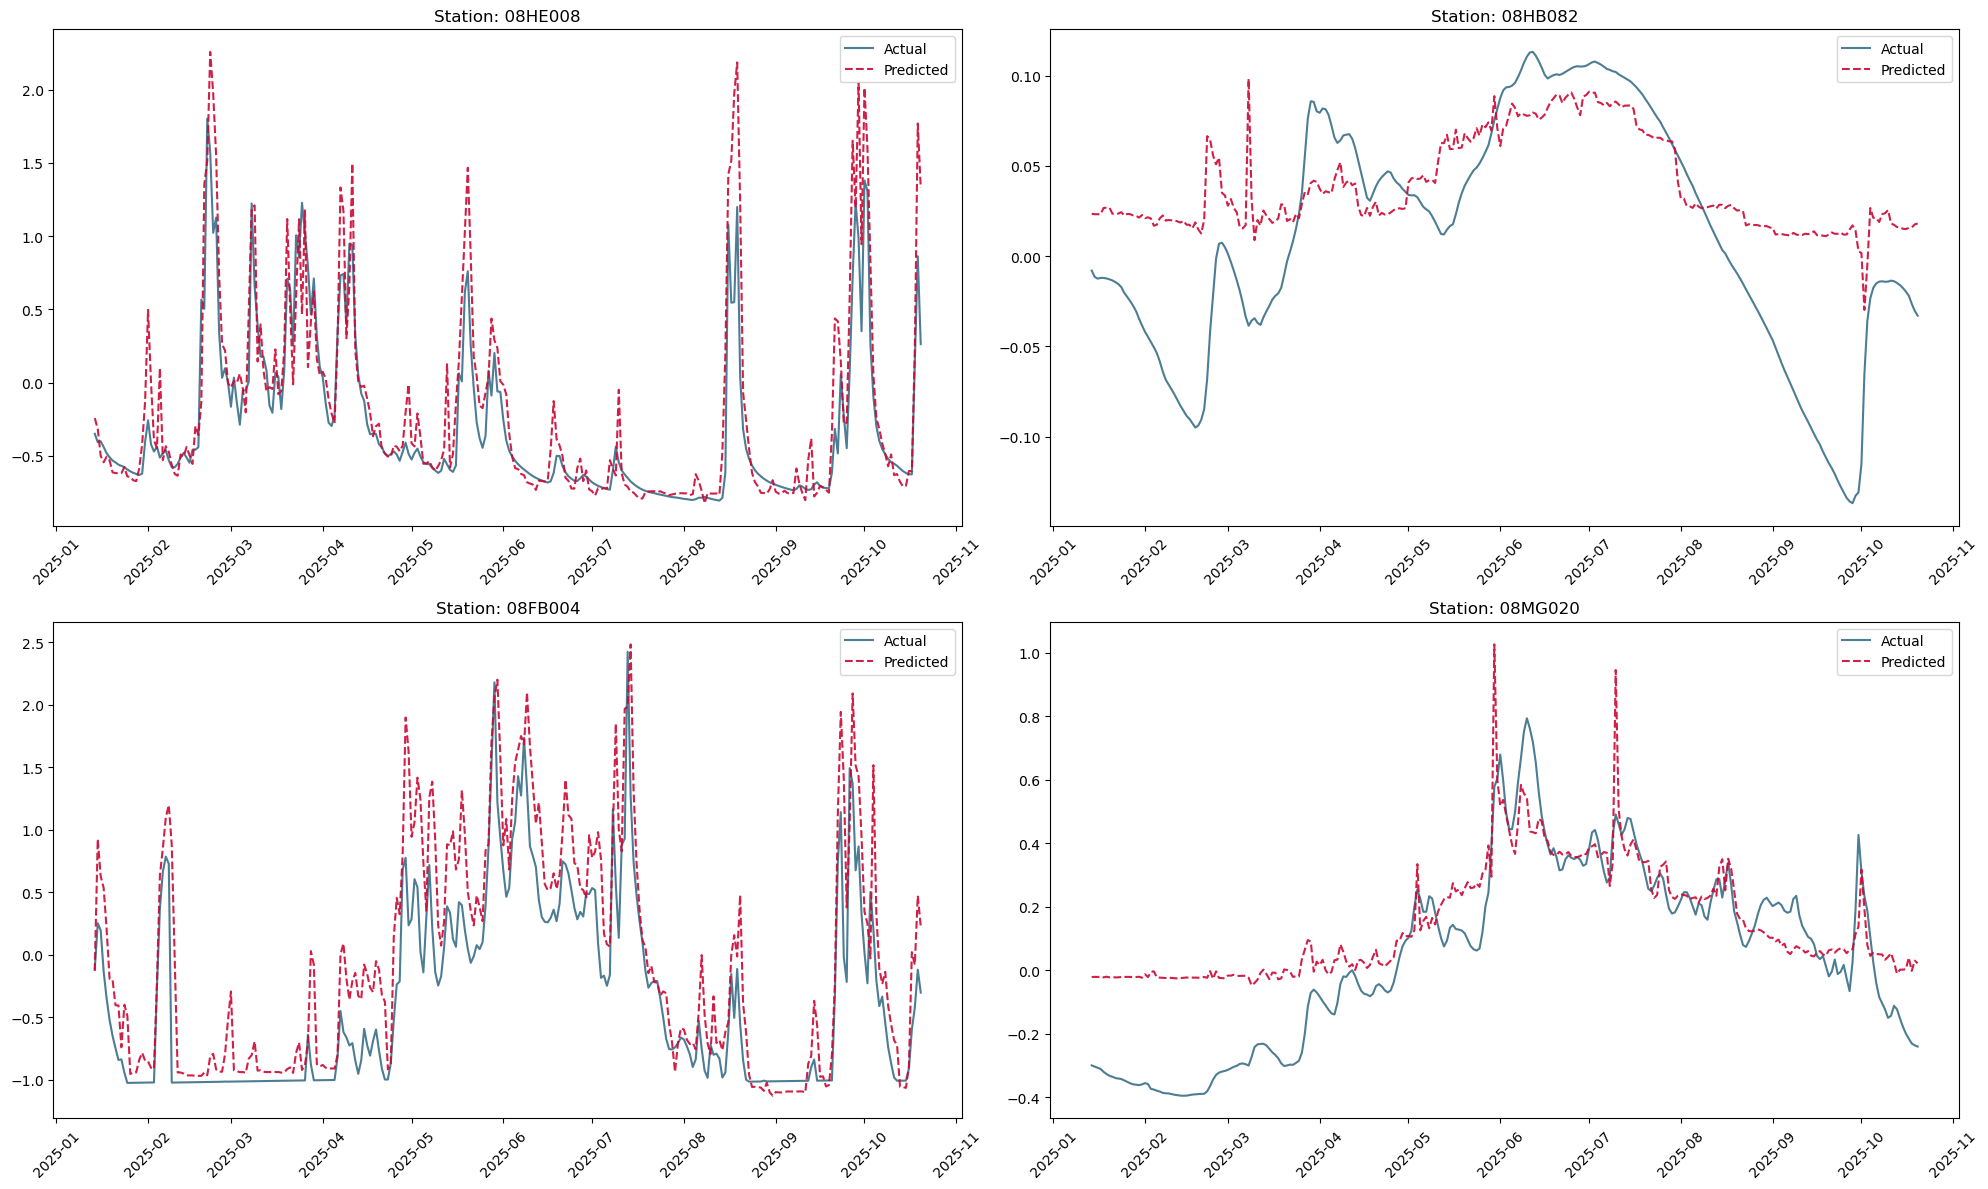

In [33]:
# Set Df to plot predicted vs Actual
X_test_cols = train.drop(columns='target').columns
test_results = pd.DataFrame(X_test, columns=X_test_cols, index=test.index)
test_results['Actual'] = y_test.values
test_results['Predicted'] = y_pred
test_results['Datetime'] = train_raw.loc[test_results.index, 'Datetime']
test_results['Hydro ID'] = train_raw.loc[test_results.index, 'Hydro ID']

# Choose random stations to plot
unique_stations = test_results['Hydro ID'].unique()
random_stations = random.sample(list(unique_stations), 4)


fig, axes = plt.subplots(2, 2, figsize=(20, 12))
axes = axes.flatten()

for i, station_id in enumerate(random_stations):
    station_data = test_results[test_results['Hydro ID'] == station_id].sort_values('Datetime')
    
    # Plot on alloted axis
    axes[i].plot(station_data['Datetime'], station_data['Actual'], label='Actual', color='#4C7D94', alpha=1)
    axes[i].plot(station_data['Datetime'], station_data['Predicted'], label='Predicted', color='#CC0633', linestyle='--', alpha=0.9)
    axes[i].set_title(f'Station: {station_id}')
    axes[i].legend()
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()

plt.show()

## Feature Importance

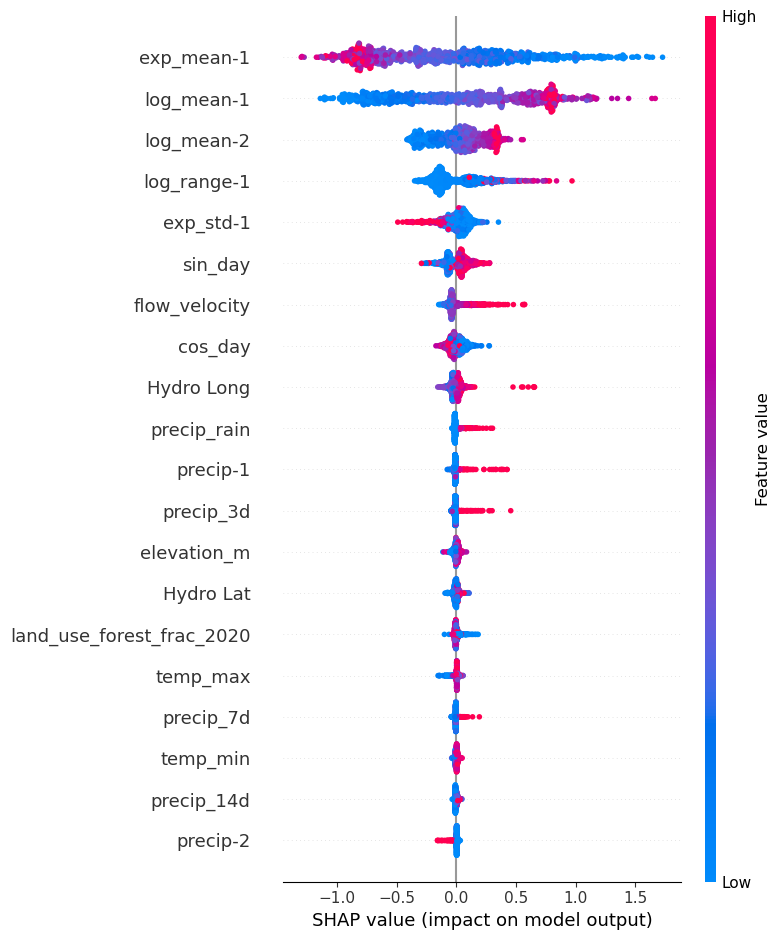

In [34]:
X_test_df = test_results.drop(columns=['Actual', 'Predicted', 'Datetime', 'Hydro ID'])

# Get Sample of Data
X_sample = X_test_df.sample(1000, random_state=15)

# Run shap Importance on model and sample 
explainer = shap.TreeExplainer(hgb)
shap_values = explainer.shap_values(X_sample)
shap.summary_plot(shap_values, X_sample, show=True)